In [1]:
from enum import Enum
import ctypes
import sys
import gc
import operator
import numpy as np
from numpy import genfromtxt
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
my_data = np.loadtxt('mnist_train.csv', delimiter=',')
train_labels = my_data[:,:1]
train_data = my_data[:,1:]
train_data = train_data.astype('float32')
train_data /= 255

In [3]:
lr = np.arange(10)

test_data = train_data[40000:]
test_labels = train_labels[40000:]
test_labels_one_hot = (lr==test_labels).astype(float)

train_data_final = train_data[:40000].tolist()
train_labels = train_labels[:40000].tolist()
train_labels_one_hot = (lr==train_labels).astype(float)


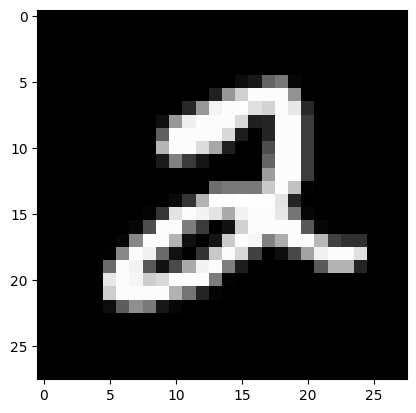

In [4]:
first_image = train_data[5]
pixels = first_image.reshape((28,28))
plt.imshow(pixels, cmap='gray')
plt.show()


In [5]:
from Neural_Network import Neural_Network
from Neural_Network import Activation_Function
from Neural_Network import Loss

In [6]:
nn = Neural_Network()
nn.add_input_layer([1,28,28])
nn.add_flatten_layer()
nn.add_fully_connected_layer(500, Activation_Function.Relu)
nn.add_fully_connected_layer(400, Activation_Function.Relu)
nn.add_fully_connected_layer(300, Activation_Function.Relu)
nn.add_fully_connected_layer(200, Activation_Function.Relu)
nn.add_fully_connected_layer(100, Activation_Function.Relu)
nn.add_fully_connected_layer(50, Activation_Function.Relu)
nn.add_output_layer(10, Activation_Function.SoftMax)

In [11]:
nn = Neural_Network()
nn.add_input_layer([1,28,28])
nn.add_convolutional_layer(32,3,1)
nn.add_maxpool_layer(2,2)
nn.add_convolutional_layer(64,3,1)
nn.add_maxpool_layer(2,2)
nn.add_flatten_layer()
nn.add_fully_connected_layer(256, Activation_Function.Relu)
nn.add_fully_connected_layer(128, Activation_Function.Relu)
nn.add_output_layer(10, Activation_Function.SoftMax)

In [12]:
nn.build()

Input layer: (1,28,28)
convolutional layer: ([32,26,26]
maxpool layer: (32,13,13)
convolutional layer: ([64,11,11]
maxpool layer: (64,5,5)
flatten layer: (1,1600)


In [13]:
nn.turn_on_l2_regularization(False)
nn.print_loss_every_iterations(1)
nn.shuffle_training_data(True)

In [16]:
nn.setLearningRate(0.001)
nn.train(train_data_final, train_labels_one_hot, 64, 3, Loss.CrossEntropy)

Starting to train neural network...Number of epochs: 3 Batch size: 64, input size: 40000
 iteration: 1 , Loss: 0.188755
Shuffling data ...
 iteration: 2 , Loss: 0.184878
Shuffling data ...
 iteration: 3 , Loss: 0.190978
Shuffling data ...
Training complete


In [ ]:
matches = 0
for index, data in enumerate(test_data):
    output = nn.execute(data)
    outputIndex, value = max(enumerate(output), key=operator.itemgetter(1))
    if outputIndex == test_labels[index][0]:
        matches += 1
match_percentage = matches / len(test_data)
print("percent correct: ")
print(match_percentage)